# 02 Exploratory Data Analysis (EDA)
Analyze cleaned datasets to discover trends, relationships, and KPIs.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"]=(8,4)

bases=pd.read_csv("../data/processed/bases_clean.csv")
equipment=pd.read_csv("../data/processed/equipment_clean.csv")
inventory=pd.read_csv("../data/processed/inventory_clean.csv")
fuel=pd.read_csv("../data/processed/fuel_logs_clean.csv",parse_dates=["Date"])
maintenance=pd.read_csv("../data/processed/maintenance_clean.csv",parse_dates=["Maintenance_Date"])
missions=pd.read_csv("../data/processed/missions_clean.csv",parse_dates=["Mission_Date"])
suppliers=pd.read_csv("../data/processed/suppliers_clean.csv")


## Dataset Shapes

In [2]:
for name,df in {
"bases":bases,"equipment":equipment,"inventory":inventory,
"fuel":fuel,"maintenance":maintenance,
"missions":missions,"suppliers":suppliers}.items():
    print(name,df.shape)


bases (30, 7)
equipment (5000, 9)
inventory (100000, 8)
fuel (120000, 8)
maintenance (50000, 10)
missions (20000, 12)
suppliers (300, 9)


## Summary Statistics

In [3]:
display(fuel.describe())
display(maintenance.describe())
display(missions.describe())


,Date,Fuel_Consumed_Liters,Fuel_Cost_INR,Fuel_Cost_Per_Liter
count,120000,120000.000000,120000.000000,120000.000000
mean,2025-12-31 16:47:44.880000,341.358565,32432.320611,95.011568
min,2025-01-01 00:00:00,40.000000,3602.350000,90.000090
25%,2025-07-03 00:00:00,129.237500,12275.362500,92.520911
50%,2025-12-31 00:00:00,289.000000,27455.110000,95.000395
75%,2026-07-02 00:00:00,528.522500,50227.977500,97.507222
max,2026-12-31 00:00:00,899.990000,89803.380000,99.999869
std,NaN,231.364096,22013.909643,2.882286


,Maintenance_Date,Downtime_Days,Maintenance_Cost_INR,Cost_Per_Day
count,50000,50000.000000,50000.000000,50000.000000
mean,2026-01-01 23:28:57.215999,6.213660,202771.685872,30143.136505
min,2025-01-01 00:00:00,0.000000,0.000000,0.000000
25%,2025-07-03 00:00:00,2.000000,69013.705000,21756.510625
50%,2026-01-01 00:00:00,4.000000,143583.715000,31146.951667
75%,2026-07-05 00:00:00,9.000000,284126.277500,40646.510167
max,2026-12-31 00:00:00,20.000000,999661.720000,49999.415714
std,NaN,5.179029,188428.229856,12938.362575


,Mission_Date,Duration_Hours,Personnel_Deployed,Budget_INR,Budget_Per_Person
count,20000,20000.000000,20000.000000,2.000000e+04,20000.000000
mean,2025-12-30 21:23:32.640000,37.914500,208.777850,2.540019e+06,20399.974510
min,2025-01-01 00:00:00,4.000000,20.000000,1.000348e+05,260.859093
25%,2025-07-01 00:00:00,21.000000,114.000000,1.327768e+06,6349.078863
50%,2025-12-30 00:00:00,38.000000,208.000000,2.551902e+06,12231.907762
75%,2026-07-01 00:00:00,55.000000,304.000000,3.750905e+06,22482.183280
max,2026-12-31 00:00:00,72.000000,400.000000,4.999462e+06,244797.160500
std,NaN,19.846662,110.150843,1.408669e+06,26196.512002


## Fuel Consumption by Region

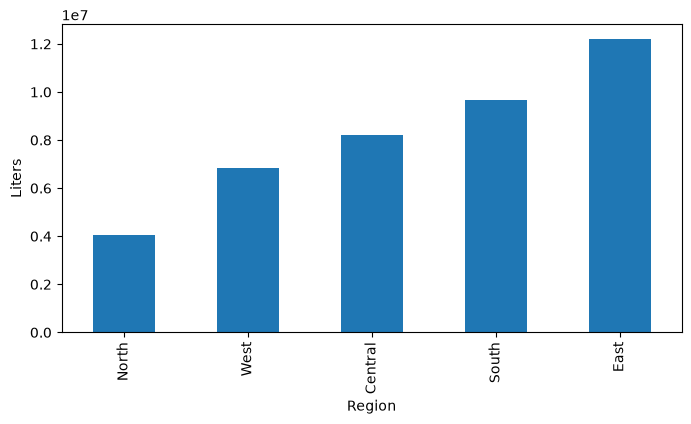

In [4]:
fuel.groupby("Region")["Fuel_Consumed_Liters"].sum().sort_values().plot(kind="bar")
plt.ylabel("Liters")
plt.show()

## Monthly Fuel Consumption

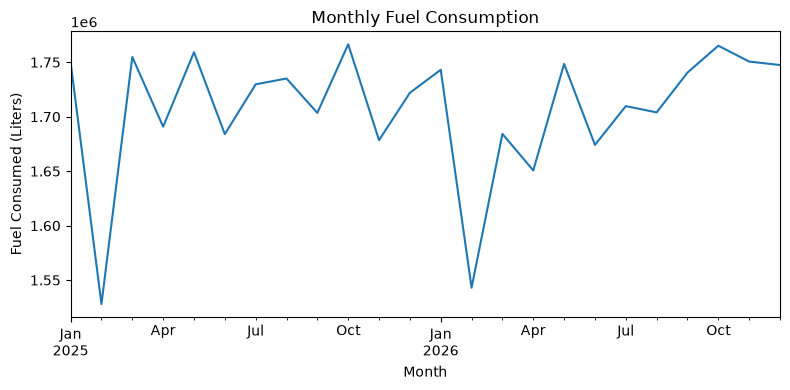

In [7]:
monthly = fuel.set_index("Date").resample("ME")["Fuel_Consumed_Liters"].sum()

monthly.plot(
    title="Monthly Fuel Consumption",
    xlabel="Month",
    ylabel="Fuel Consumed (Liters)"
)

plt.tight_layout()
plt.show()

## Inventory Status

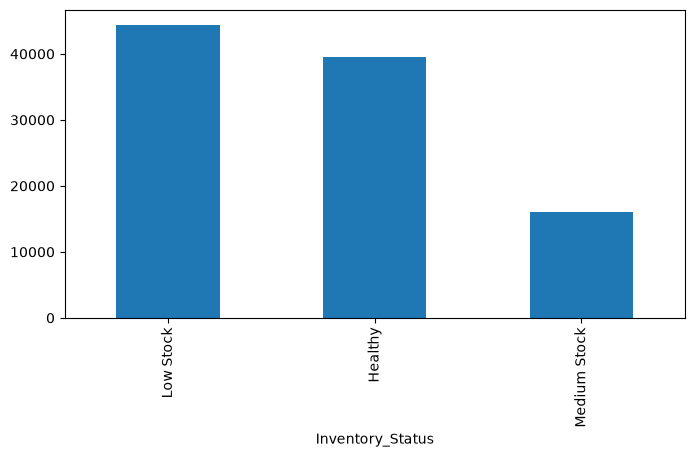

In [8]:
inventory["Inventory_Status"].value_counts().plot(kind="bar")
plt.show()

## Equipment Status

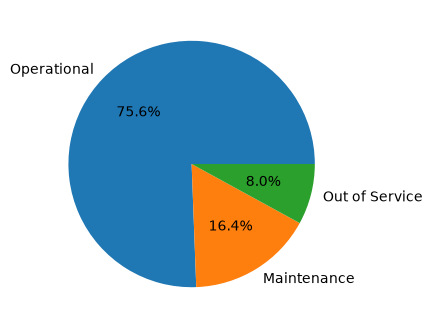

In [9]:
equipment["Status"].value_counts().plot(kind="pie",autopct="%1.1f%%")
plt.ylabel("")
plt.show()

## Maintenance Cost Distribution

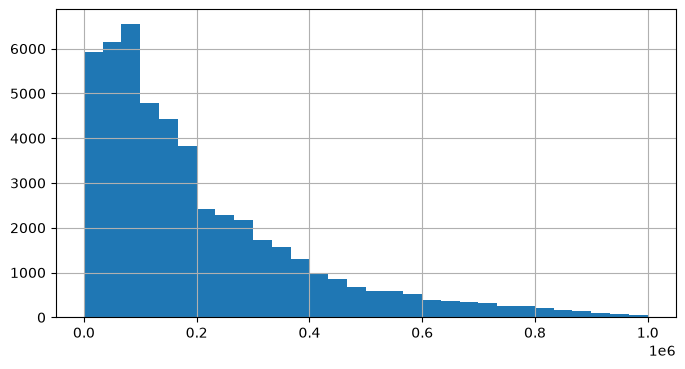

In [10]:
maintenance["Maintenance_Cost_INR"].hist(bins=30)
plt.show()

## Average Maintenance Cost by Type

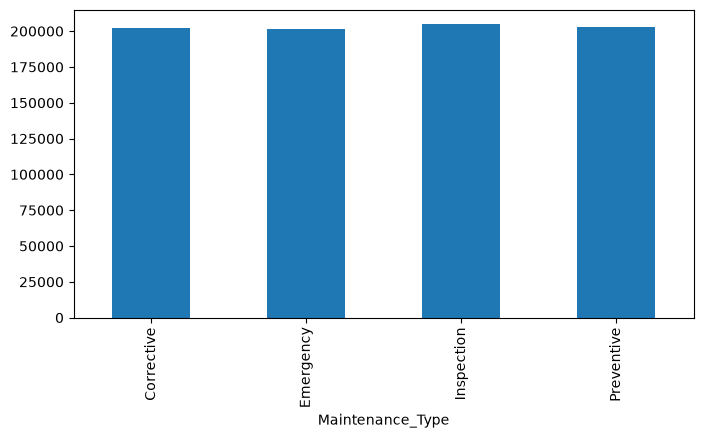

In [11]:
maintenance.groupby("Maintenance_Type")["Maintenance_Cost_INR"].mean().plot(kind="bar")
plt.show()

## Mission Status

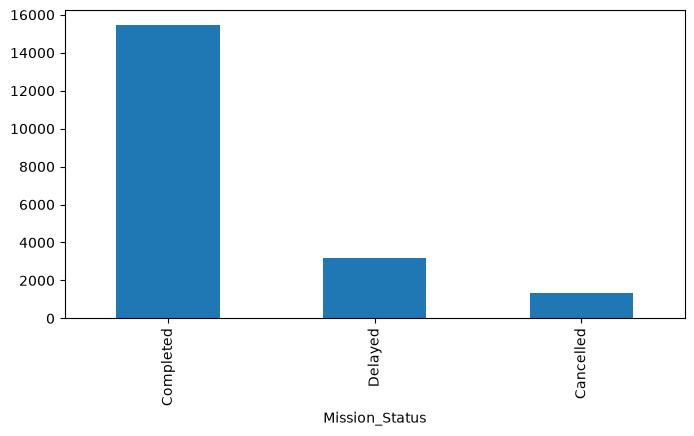

In [12]:
missions["Mission_Status"].value_counts().plot(kind="bar")
plt.show()

## Mission Budget by Priority

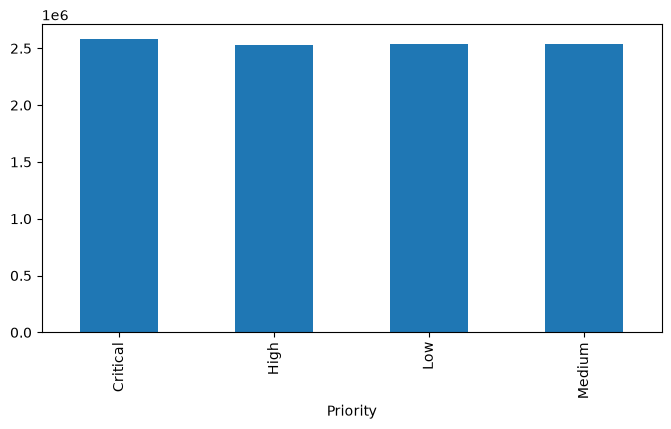

In [13]:
missions.groupby("Priority")["Budget_INR"].mean().plot(kind="bar")
plt.show()

## Supplier Quality Ratings

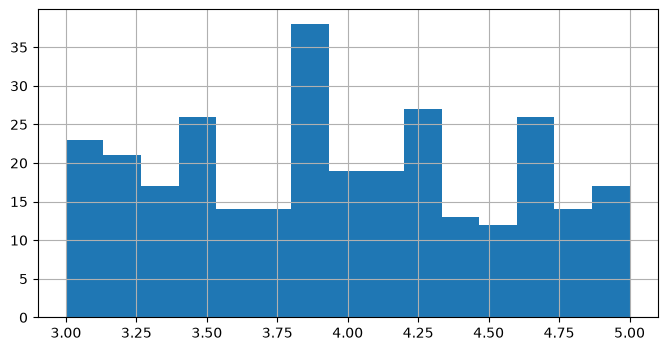

In [14]:
suppliers["Quality_Rating"].hist(bins=15)
plt.show()

## Top 10 Suppliers by Contract Value

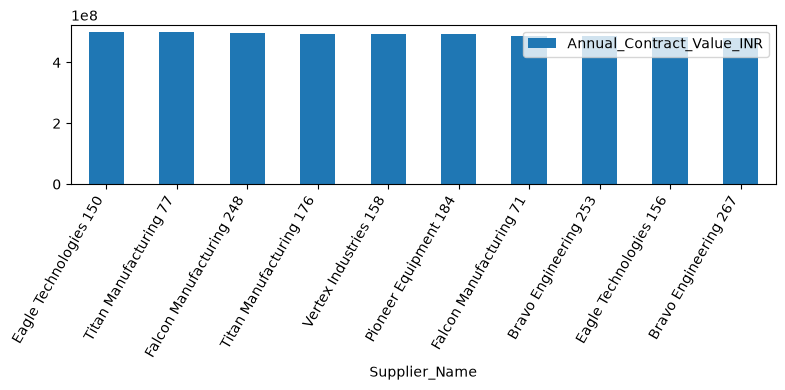

In [15]:
suppliers.nlargest(10,"Annual_Contract_Value_INR").plot(
x="Supplier_Name",y="Annual_Contract_Value_INR",kind="bar")
plt.xticks(rotation=60,ha="right")
plt.tight_layout()
plt.show()

## Correlation Analysis

In [16]:
corr=maintenance[["Downtime_Days","Maintenance_Cost_INR","Cost_Per_Day"]].corr()
print(corr)


                      Downtime_Days  Maintenance_Cost_INR  Cost_Per_Day
Downtime_Days              1.000000              0.900751      0.230909
Maintenance_Cost_INR       0.900751              1.000000      0.468135
Cost_Per_Day               0.230909              0.468135      1.000000


## Key KPIs

In [17]:
print("Total Missions:",len(missions))
print("Total Fuel Consumed:",round(fuel["Fuel_Consumed_Liters"].sum(),2))
print("Total Maintenance Cost:",round(maintenance["Maintenance_Cost_INR"].sum(),2))
print("Low Stock Items:",(inventory["Inventory_Status"]=="Low Stock").sum())


Total Missions: 20000
Total Fuel Consumed: 40963027.84
Total Maintenance Cost: 10138584293.62
Low Stock Items: 44450


## Business Insights
- Identify high fuel-consuming regions.
- Monitor low-stock inventory.
- Compare maintenance cost by type.
- Analyze mission priorities and budgets.
- Evaluate supplier performance.